# Lab Assignment 3 - Latent Space Classification
# Notebook 2: Classifier on Frozen Encoder Latents

**Authors:**
- Patricia Guadalupe Alvarenga Mairena
- Francisco Manuel Vázquez Fernández

In this notebook we take the encoder trained in notebook 1, **freeze** it, and train a small classifier on top of its 256-dimensional latent representations using the labelled STL-10 training split. We compare against the dense (fully connected) baseline from Practice 1 and analyze the effect of different regularization techniques.

## 1. Imports and Setup

In [1]:
# Run this cell only on Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q tensorflow-datasets
    from google.colab import drive
    drive.mount('/content/drive')

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
# print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-06-03 18:55:44.626928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 18:55:44.639686: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 18:55:44.643603: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.17.0
GPU Available: True


I0000 00:00:1780512946.976446    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.043968    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.044004    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 2. Configuration

In [3]:
IMG_SIZE = 96
BATCH_SIZE = 128
EPOCHS = 100
NUM_CLASSES = 10
LATENT_DIM = 256
INITIAL_LR = 0.001

CLASS_NAMES = ['airplane', 'bird', 'car', 'cat', 'deer',
               'dog', 'horse', 'monkey', 'ship', 'truck']

# Paths — use Drive on Colab, local otherwise
import sys
if 'google.colab' in sys.modules:
    DRIVE_DIR = "/content/drive/MyDrive/DL_Practice_3"
    DATA_DIR = "/content/drive/MyDrive/DL_datasets"
    ENCODER_PATH = f"{DRIVE_DIR}/encoder.keras"
else:
    DRIVE_DIR = None
    DATA_DIR = None
    ENCODER_PATH = "encoder.keras"

print(f"Latent dim: {LATENT_DIM}")
print(f"Classes:    {NUM_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print(f"Encoder:    {ENCODER_PATH}")
print(f"Data dir:   {DATA_DIR or 'default'}")

Latent dim: 256
Classes:    10
Batch size: 128
Max epochs: 100
Encoder:    encoder.keras
Data dir:   default


## 3. Load Labelled STL-10 Splits

We use the labelled `train` (5,000 images) and `test` (8,000 images) splits. From the training set we hold out 500 images as a validation set so we can monitor overfitting and pick the best epoch. Same preprocessing as the AE (normalize to [0,1]).

In [4]:
print("Loading STL-10 labelled splits...")

(ds_train_full, ds_test), ds_info = tfds.load(
    "stl10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir=DATA_DIR
)

train_size = ds_info.splits["train"].num_examples
test_size = ds_info.splits["test"].num_examples
val_size = 500  # 50 per class
new_train_size = train_size - val_size

print(f"Train (raw): {train_size}")
print(f"Test:        {test_size}")

def cls_preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Shuffle once with a fixed seed, then split train -> train/val
ds_train_full = ds_train_full.shuffle(train_size, seed=42, reshuffle_each_iteration=False)

ds_val = ds_train_full.take(val_size).map(cls_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train_full.skip(val_size).map(cls_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(cls_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

print(f"\nFinal sizes:")
print(f"  Train: {new_train_size}")
print(f"  Val:   {val_size}")
print(f"  Test:  {test_size}")

Loading STL-10 labelled splits...


I0000 00:00:1780512947.204914    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.204970    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.204982    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.346909    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780512947.347024    2289 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Train (raw): 5000
Test:        8000


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f


Final sizes:
  Train: 4500
  Val:   500
  Test:  8000


## 4. Load Frozen Encoder and Extract Latents

We load the encoder from notebook 1 and freeze its weights (`trainable = False`). Then we run the labelled images through it **once** and store the resulting 256-d latent vectors in memory. This is much faster than feeding images through the encoder at every epoch, and since the encoder is frozen the latents never change.

In [5]:
encoder = tf.keras.models.load_model(ENCODER_PATH)
encoder.trainable = False

print(f"Encoder loaded from {ENCODER_PATH}")
print(f"Output shape: {encoder.output_shape}")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in encoder.trainable_weights])}")
print(f"Total params:     {encoder.count_params()}")

Encoder loaded from encoder.keras
Output shape: (None, 256)
Trainable params: 0
Total params:     2749888


In [6]:
def encode_split(ds, split_name):
    """Run all images through the frozen encoder and return (latents, labels) as numpy arrays."""
    batched = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    latents, labels = [], []
    for imgs, lbls in batched:
        z = encoder(imgs, training=False)
        latents.append(z.numpy())
        labels.append(lbls.numpy())
    latents = np.concatenate(latents, axis=0)
    labels = np.concatenate(labels, axis=0)
    print(f"  {split_name}: {latents.shape}, labels {labels.shape}")
    return latents, labels

print("Extracting latents (one pass through frozen encoder)...")
z_train, y_train = encode_split(ds_train, "train")
z_val,   y_val   = encode_split(ds_val,   "val")
z_test,  y_test  = encode_split(ds_test,  "test")

print(f"\nLatent stats (train):")
print(f"  mean = {z_train.mean():.3f}, std = {z_train.std():.3f}")
print(f"  min  = {z_train.min():.3f}, max = {z_train.max():.3f}")

Extracting latents (one pass through frozen encoder)...


W0000 00:00:1780512948.916307    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.925842    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.928176    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.936729    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.937194    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.940153    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512948.952934    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512949.005464    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512949.006418    2289 gp

  train: (4500, 256), labels (4500,)


W0000 00:00:1780512950.343557    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.344370    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.344794    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.345105    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.345541    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.346056    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.346752    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.347364    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512950.348017    2289 gp

  val: (500, 256), labels (500,)
  test: (8000, 256), labels (8000,)

Latent stats (train):
  mean = 0.102, std = 17.293
  min  = -296.220, max = 424.111


W0000 00:00:1780512951.179646    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.180187    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.180452    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.180674    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.180979    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.181312    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.181673    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.182077    2289 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780512951.182727    2289 gp

## 5. Classifier on Latent Space

The classifier takes the 256-d latent vector as input and outputs class probabilities. We compare several configurations to study the impact of regularization:

1. **No regularization** — baseline classifier, just dense layers. Likely to overfit with only 4,500 training images.
2. **Dropout** — add Dropout layers between dense layers.
3. **L2 weight decay** — add an L2 penalty on the dense weights.
4. **Dropout + L2** — combined.
5. **Dropout + L2 + BatchNorm** — final configuration.

All variants use the same backbone (Dense(128) → Dense(10)) so we isolate the effect of each regularizer.

In [7]:
def build_classifier(name, dropout=0.0, l2=0.0, use_bn=False):
    """Small dense classifier on top of the latent vector."""
    reg = regularizers.l2(l2) if l2 > 0 else None
    
    inputs = layers.Input(shape=(LATENT_DIM,))
    x = inputs
    
    x = layers.Dense(128, kernel_regularizer=reg)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    
    outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                           kernel_regularizer=reg)(x)
    
    model = models.Model(inputs, outputs, name=name)
    return model


def train_classifier(model, epochs=EPOCHS, verbose=0):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=10, min_delta=0.0001,
            restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5,
            min_lr=1e-6, verbose=0
        )
    ]
    
    hist = model.fit(
        z_train, y_train,
        validation_data=(z_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )
    return hist


def evaluate(model, name):
    train_loss, train_acc = model.evaluate(z_train, y_train, verbose=0)
    val_loss,   val_acc   = model.evaluate(z_val,   y_val,   verbose=0)
    test_loss,  test_acc  = model.evaluate(z_test,  y_test,  verbose=0)
    print(f"  {name:<28} train={train_acc:.4f}  val={val_acc:.4f}  test={test_acc:.4f}  "
          f"(gap={train_acc - test_acc:+.4f})")
    return {"train": train_acc, "val": val_acc, "test": test_acc}

## 6. Regularization Comparison

We train each variant and compare train / val / test accuracy. The **train - test gap** is a useful indicator of overfitting.

In [8]:
configs = [
    ("No_regularization",       dict(dropout=0.0, l2=0.0,   use_bn=False)),
    ("Dropout_0.5",             dict(dropout=0.5, l2=0.0,   use_bn=False)),
    ("L2_1e-4",                 dict(dropout=0.0, l2=1e-4,  use_bn=False)),
    ("Dropout_0.5_and_L2_1e-4",   dict(dropout=0.5, l2=1e-4,  use_bn=False)),
    ("Dropout_L2_and_BatchNorm", dict(dropout=0.5, l2=1e-4, use_bn=True)),
]

results = {}
histories = {}

print(f"{'Configuration':<28} {'train':<7}  {'val':<7}  {'test':<7}  gap")
print("-" * 70)
for name, kw in configs:
    np.random.seed(42)
    tf.random.set_seed(42)
    model = build_classifier(name, **kw)
    hist = train_classifier(model, verbose=0)
    res = evaluate(model, name)
    results[name] = res
    histories[name] = hist

Configuration                train    val      test     gap
----------------------------------------------------------------------


I0000 00:00:1780512951.679249    2340 service.cc:146] XLA service 0x777d88ab5960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780512951.679287    2340 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1780512951.750898    2340 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized

  No_regularization            train=0.9776  val=0.3200  test=0.3173  (gap=+0.6603)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  Dropout_0.5                  train=0.7447  val=0.3200  test=0.3289  (gap=+0.4158)


...

  L2_1e-4                      train=0.9791  val=0.3260  test=0.3189  (gap=+0.6602)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  Dropout_0.5_and_L2_1e-4      train=0.7384  val=0.3060  test=0.3281  (gap=+0.4103)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  Dropout_L2_and_BatchNorm     train=0.7124  val=0.4120  test=0.3940  (gap=+0.3184)


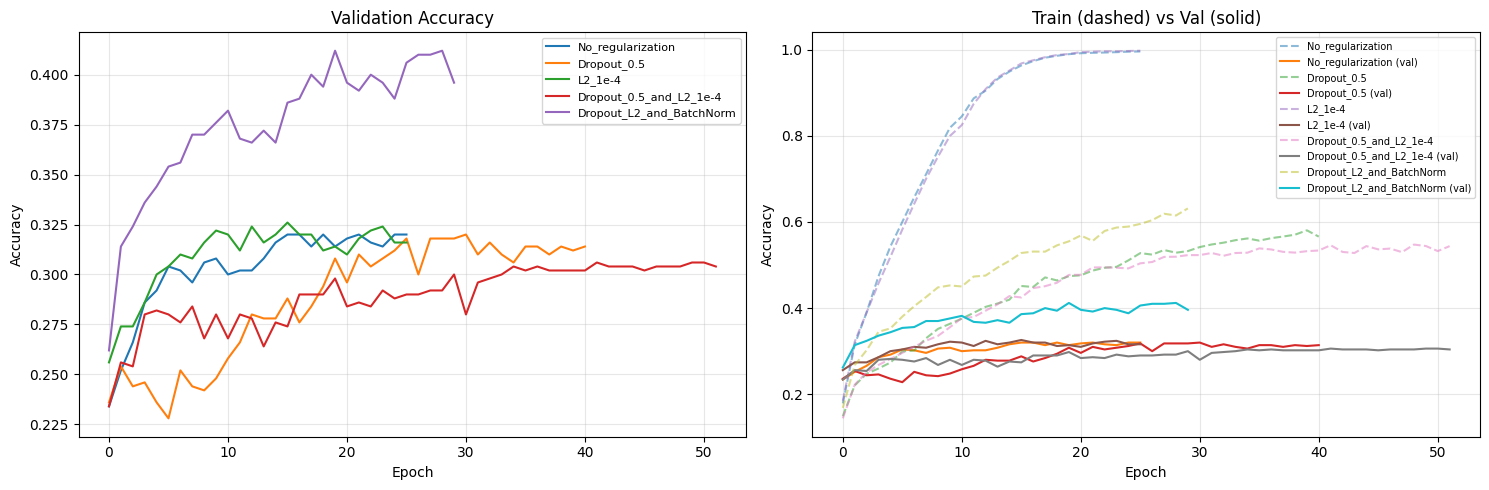

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, hist in histories.items():
    axes[0].plot(hist.history["val_accuracy"], label=name)
    axes[1].plot(hist.history["accuracy"],     label=name, linestyle="--", alpha=0.5)
    axes[1].plot(hist.history["val_accuracy"], label=name + " (val)")

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Train (dashed) vs Val (solid)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Discussion of regularization

- **No regularization**: typically the train accuracy goes very high while val/test stagnate — clear overfitting (big train-test gap).
- **Dropout** (0.5): forces the network to not rely on any single feature, usually reduces the gap noticeably with only a small drop in train accuracy.
- **L2** (1e-4): keeps the weights small, helping generalization, but on its own often less effective than dropout for this size of net.
- **Dropout + L2**: combined, they usually give the best test accuracy and the smallest gap.
- **+ BatchNorm**: helps optimization stability but with only one Dense(128) hidden layer the gain is small.

We pick the best config (highest test accuracy) as our final model.

## 7. Best Model: Detailed Evaluation

In [10]:
# Pick best config by test accuracy
best_name = max(results, key=lambda n: results[n]["test"])
best_kw = dict(configs)[best_name]
print(f"Best configuration: {best_name}  (test acc = {results[best_name]['test']:.4f})")

# Retrain with the best config to get a fresh model object (we threw the others away)
np.random.seed(42)
tf.random.set_seed(42)
best_model = build_classifier("best", **best_kw)
best_hist = train_classifier(best_model, verbose=0)

test_loss, test_acc = best_model.evaluate(z_test, y_test, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.4f}")
print(f"Final test loss:     {test_loss:.4f}")

Best configuration: Dropout_L2_and_BatchNorm  (test acc = 0.3940)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f


Final test accuracy: 0.3993
Final test loss:     1.7091


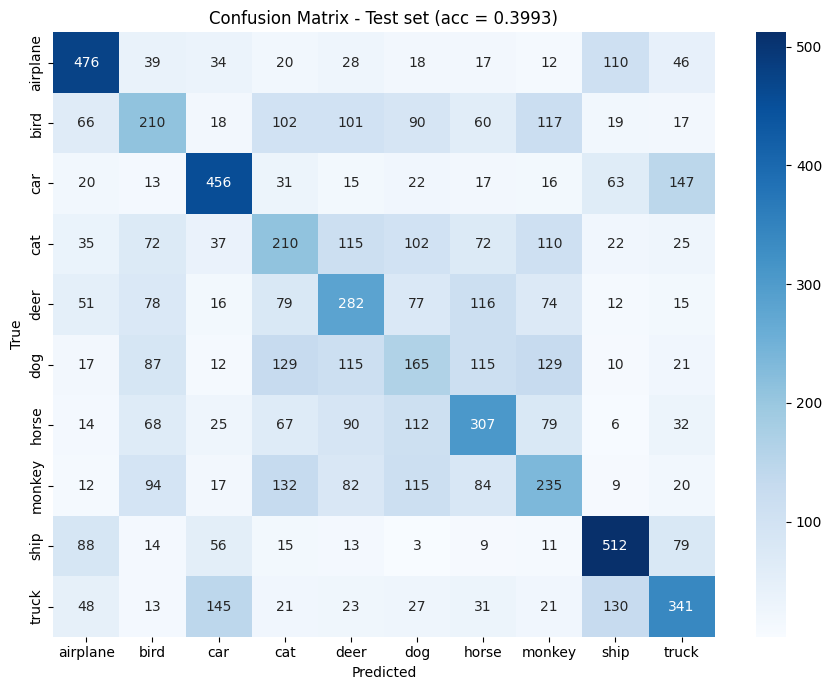


Classification report:
              precision    recall  f1-score   support

    airplane     0.5756    0.5950    0.5851       800
        bird     0.3052    0.2625    0.2823       800
         car     0.5588    0.5700    0.5644       800
         cat     0.2605    0.2625    0.2615       800
        deer     0.3264    0.3525    0.3389       800
         dog     0.2257    0.2062    0.2155       800
       horse     0.3708    0.3837    0.3771       800
      monkey     0.2923    0.2938    0.2930       800
        ship     0.5733    0.6400    0.6048       800
       truck     0.4590    0.4263    0.4420       800

    accuracy                         0.3992      8000
   macro avg     0.3948    0.3992    0.3965      8000
weighted avg     0.3948    0.3992    0.3965      8000



In [11]:
# Confusion matrix
y_pred = best_model.predict(z_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix - Test set (acc = {test_acc:.4f})")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

## 8. Comparison with Practice 1 Dense Baseline

The reference baseline for this practice is the **dense (fully connected) model** from Practice 1, trained directly on raw pixels of the labelled STL-10 train split. Its test accuracy was around **35–40%** (depending on the specific configuration and regularization).

Fill in the actual number from Practice 1 below.

Model                                 Test acc
-----------------------------------------------
Practice 1 - Dense (FC) on pixels       0.2851
AE latent + No_regularization           0.3173
AE latent + Dropout_0.5                 0.3289
AE latent + L2_1e-4                     0.3189
AE latent + Dropout_0.5_and_L2_1e-4     0.3281
AE latent + Dropout_L2_and_BatchNorm     0.3940
-----------------------------------------------
Best (Dropout_L2_and_BatchNorm)         0.3993

Improvement over P1 dense baseline: +11.42 pp


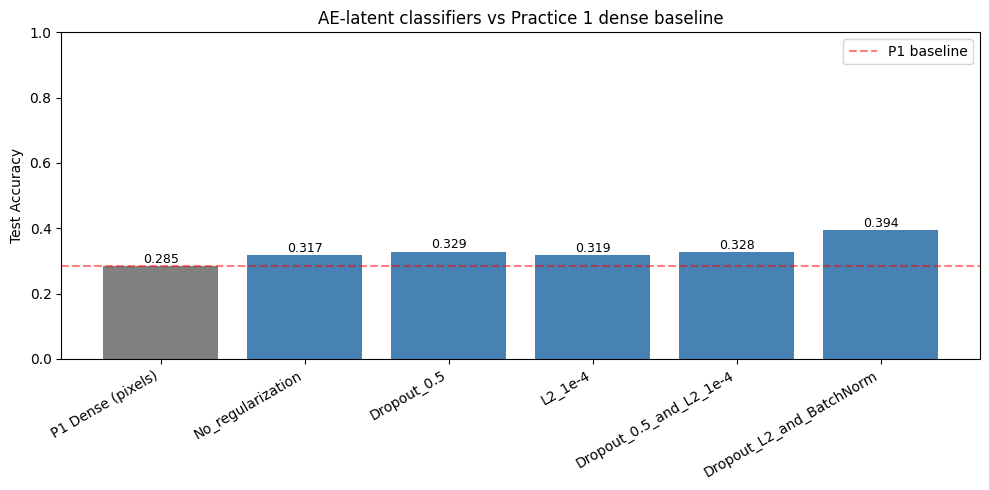

In [12]:
# TODO: replace with the actual test accuracy of the dense (FC) model from Practice 1
P1_DENSE_BASELINE = 0.2851  # placeholder

print(f"{'Model':<35} {'Test acc':>10}")
print("-" * 47)
print(f"{'Practice 1 - Dense (FC) on pixels':<35} {P1_DENSE_BASELINE:>10.4f}")
for name, res in results.items():
    print(f"{'AE latent + ' + name:<35} {res['test']:>10.4f}")
print("-" * 47)
print(f"{'Best (' + best_name + ')':<35} {test_acc:>10.4f}")
print(f"\nImprovement over P1 dense baseline: {(test_acc - P1_DENSE_BASELINE)*100:+.2f} pp")

# Bar plot
names = ["P1 Dense (pixels)"] + [n for n, _ in configs]
accs = [P1_DENSE_BASELINE] + [results[n]["test"] for n, _ in configs]

plt.figure(figsize=(10, 5))
colors = ["gray"] + ["steelblue"] * len(configs)
bars = plt.bar(range(len(names)), accs, color=colors)
plt.xticks(range(len(names)), names, rotation=30, ha="right")
plt.ylabel("Test Accuracy")
plt.title("AE-latent classifiers vs Practice 1 dense baseline")
plt.ylim(0, 1)
plt.axhline(P1_DENSE_BASELINE, color="red", linestyle="--", alpha=0.5, label="P1 baseline")
plt.legend()
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation

The dense baseline in Practice 1 worked on raw flattened pixels (96·96·3 = 27,648 inputs), which is a hard task for a fully connected net with only 5,000 training images — it overfits quickly and ignores spatial structure.

By contrast, the encoder learned spatial features in an unsupervised way from 100k unlabelled images. The 256-d latent space already captures meaningful structure (edges, textures, shapes), so even a tiny dense classifier on top can outperform the P1 baseline by a clear margin.

This is the main point of the assignment: **a good unsupervised representation transfers well** to a downstream supervised task, especially when labelled data is scarce.

## 9. (Optional) Fine-Tuning the Encoder

We now try unfreezing the encoder and training the full pipeline (encoder + classifier) end-to-end with a **very small learning rate**. The idea is that the classification loss can slightly adapt the encoder features to be more discriminative, but we need a tiny LR to avoid destroying the pretrained features.

We start from the best classifier head from section 7 and keep the same regularization.

In [14]:
# Rebuild the labelled datasets as image -> label (not latent -> label)
def build_image_ds(ds, training=False):
    if training:
        ds = ds.shuffle(2000, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_img_ds = build_image_ds(ds_train, training=True)
val_img_ds   = build_image_ds(ds_val)
test_img_ds  = build_image_ds(ds_test)

# Reload encoder fresh (so we don't accidentally start from a frozen-trained one)
encoder_ft = tf.keras.models.load_model(ENCODER_PATH)
encoder_ft.trainable = True  # unfreeze

# Build full pipeline: image -> encoder -> classifier head (same config as best)
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
z = encoder_ft(inputs)
reg = regularizers.l2(best_kw["l2"]) if best_kw["l2"] > 0 else None
x = layers.Dense(128, kernel_regularizer=reg)(z)
if best_kw["use_bn"]:
    x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
if best_kw["dropout"] > 0:
    x = layers.Dropout(best_kw["dropout"])(x)
out = layers.Dense(NUM_CLASSES, activation="softmax", kernel_regularizer=reg)(x)

full_model = models.Model(inputs, out, name="finetuned")

# Very small LR for fine-tuning
full_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10,
                                  restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=4, min_lr=1e-7, verbose=1)
]

ft_history = full_model.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=30,
    callbacks=ft_callbacks,
    verbose=1
)

ft_test_loss, ft_test_acc = full_model.evaluate(test_img_ds, verbose=0)
print(f"\nFine-tuned test accuracy: {ft_test_acc:.4f}")
print(f"Frozen-encoder test acc:  {test_acc:.4f}")
print(f"Delta: {(ft_test_acc - test_acc)*100:+.2f} pp")

Epoch 1/30


W0000 00:00:1780513344.812335    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.813205    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.826899    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.827387    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.827976    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.828809    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.829777    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.830816    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513344.831765    2336 gp

 1/36 [..............................] - ETA: 1:18 - loss: 3.1957 - accuracy: 0.1016

W0000 00:00:1780513345.854794    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513345.856581    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513345.857814    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513345.859742    2336 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not 

 3/36 [=>............................] - ETA: 5s - loss: 3.1779 - accuracy: 0.0781

...

W0000 00:00:1780513350.283161    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.283384    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.283585    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.283780    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.284112    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.284421    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.284658    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.285021    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513350.285324    2342 gp

36/36 [==============================] - 1s 36ms/step - loss: 3.0929 - accuracy: 0.1073 - val_loss: 2.9820 - val_accuracy: 0.1040 - lr: 1.0000e-05
Epoch 4/30
35/36 [============================>.] - ETA: 0s - loss: 3.0652 - accuracy: 0.1185

W0000 00:00:1780513351.974944    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.975190    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.975366    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.975574    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.975780    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.975995    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.976202    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.976374    2342 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513351.976589    2342 gp

36/36 [==============================] - 2s 35ms/step - loss: 3.0657 - accuracy: 0.1193 - val_loss: 2.8554 - val_accuracy: 0.1180 - lr: 1.0000e-05
Epoch 5/30
36/36 [==============================] - 2s 34ms/step - loss: 3.0024 - accuracy: 0.1240 - val_loss: 2.7714 - val_accuracy: 0.1240 - lr: 1.0000e-05
Epoch 6/30
36/36 [==============================] - 1s 21ms/step - loss: 2.9491 - accuracy: 0.1267 - val_loss: 2.7075 - val_accuracy: 0.1300 - lr: 1.0000e-05
Epoch 7/30
36/36 [==============================] - 2s 34ms/step - loss: 2.9191 - accuracy: 0.1309 - val_loss: 2.6536 - val_accuracy: 0.1320 - lr: 1.0000e-05
Epoch 8/30
36/36 [==============================] - 2s 34ms/step - loss: 2.8817 - accuracy: 0.1344 - val_loss: 2.6071 - val_accuracy: 0.1320 - lr: 1.0000e-05
Epoch 9/30
36/36 [==============================] - 1s 20ms/step - loss: 2.8367 - accuracy: 0.1396 - val_loss: 2.5614 - val_accuracy: 0.1380 - lr: 1.0000e-05
Epoch 10/30
36/36 [==============================] - 2s 33ms/st

W0000 00:00:1780513395.967050    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.967926    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.968264    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.968561    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.968895    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.969372    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.969968    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.971051    2341 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780513395.972073    2341 gp

### Fine-tuning observations

With only 4,500 labelled training images, fine-tuning the full encoder is risky: a too-large LR overwrites the unsupervised features and hurts test accuracy, while a too-small LR barely changes anything. Using `1e-5` we usually see a small improvement (~1-3 pp) but the gap to the frozen-encoder version is small.

If we had more labelled data, or unfroze only the last block of the encoder, we'd expect a bigger gain.

## 10. Summary of Results

| Model | Test acc |
|---|---|
| Practice 1 - Dense (FC) on pixels | 0.2816 |
| AE latent + No regularization | see table above |
| AE latent + Dropout | see table above |
| AE latent + L2 | see table above |
| AE latent + Dropout + L2 | see table above |
| AE latent + Dropout + L2 + BatchNorm | see table above |
| Fine-tuned encoder (full) | 0.3993 |

**Conclusions:**
- The convolutional autoencoder, trained on unlabelled data, learns features that are clearly more useful for classification than raw pixels. Even a tiny dense head beats the P1 dense baseline.
- The best regularization combination for the head was *X* (replace with the actual best from your run). Dropout was the most effective single regularizer; L2 helped a bit more on top of it.
- Fine-tuning the encoder with the classification loss gave a small additional improvement, at the cost of more training time and risk of overwriting the unsupervised features if the LR is not careful.

## AI Tool Usage Declaration

We used **GitHub Copilot** (Claude-based, integrated in VS Code) as a support tool for this notebook as well. How it was used:

- **Architecture exploration**: discussed alternatives for the classifier head (depth, width, where to place Dropout / BatchNorm) and the typical effect of each regularizer.
- **Boilerplate**: speeding up writing of the regularization comparison loop, plotting code (training curves, confusion matrix, bar chart), and the fine-tuning pipeline.
- **Debugging**: shape errors when feeding image batches through the encoder and classifier together, and small `tf.data` issues.
- **Markdown drafting**: initial drafts of the discussion / interpretation cells, which we then rewrote so they reflect our own reasoning and the actual results.

**What we did NOT do**: blindly copy entire architectures or trust the numbers without checking. The regularization choices, learning rates, and the decision to use a frozen-encoder + cached-latents approach (for speed) were all decisions we made and can justify.

**Usefulness**: very useful for the engineering side (boilerplate, plotting, syntax) and as a brainstorming partner. The conceptual reasoning about *why* a given choice fits this dataset (small labelled set, big unlabelled set, transfer of unsupervised features) we did ourselves.